# Mastering Seaborn for AI/ML — Part 2
### Matrix Plots → Grids → Styling → Statistics → EDA & ML Workflows → Evaluation → Projects → Cheat Sheet

This continues directly from Part 1. If you're starting here, run the setup cell below
first it re-creates the datasets and theme used throughout.



In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

titanic = sns.load_dataset("titanic")
tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")
penguins = sns.load_dataset("penguins").dropna()

print("Datasets loaded:", titanic.shape, tips.shape, iris.shape, penguins.shape)


Datasets loaded: (891, 15) (244, 7) (150, 5) (333, 7)


## Part 8 — Matrix Plots

### `sns.heatmap()`
Displays a 2D grid of values as colour, with optional numeric annotation. This is one of
the **most heavily used Seaborn functions in real ML work**, because it's the standard
way to visualise:

- **Correlation matrices** — which features move together (and which are redundant)
- **Confusion matrices** — how a classifier's predictions compare to true labels
- **Missing-value patterns** — where NaNs cluster across rows/columns
- **Pivot tables** — any 2D summary (e.g. average value per (row-category, col-category) pair)

Key parameters:

| Parameter | Purpose |
|---|---|
| `annot=True` | prints the numeric value inside each cell |
| `fmt` | number format for annotations, e.g. `".2f"` |
| `cmap` | colour map — use a **diverging** map (`"coolwarm"`, `"RdBu_r"`) for data with a meaningful zero (like correlation, −1 to 1); use a **sequential** map (`"viridis"`, `"Blues"`) for data with no meaningful zero (like raw counts) |
| `center` | value to treat as the colour midpoint (usually `0` for correlation) |
| `vmin`, `vmax` | fix the colour scale range so multiple heatmaps are comparable |
| `linewidths`, `linecolor` | grid lines between cells, improves readability |
| `mask` | hide part of the matrix (commonly the upper triangle of a correlation matrix, since it's a mirror of the lower triangle) |
| `square=True` | force square cells |


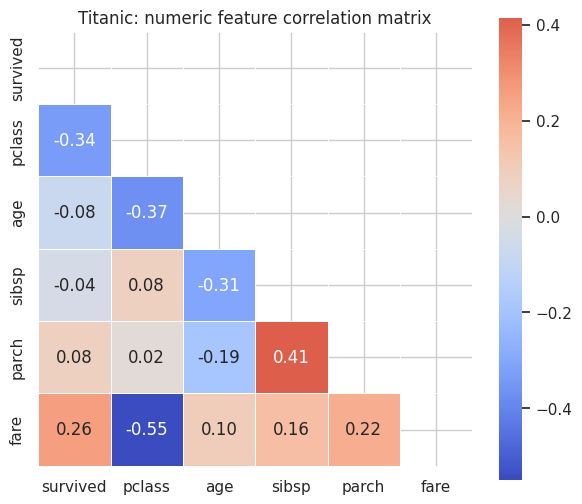

In [2]:
numeric_df = titanic.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide the redundant upper triangle

plt.figure(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Titanic: numeric feature correlation matrix")
plt.show()


**How to read this correctly:**
- Values close to **+1**: strongly positively correlated (as one goes up, so does the other)
- Values close to **−1**: strongly negatively correlated (as one goes up, the other goes down)
- Values close to **0**: little to no *linear* relationship (note: correlation only
  captures *linear* relationships — two variables can be strongly related in a non-linear
  way and still show a correlation near 0, so don't treat a low value as "no
  relationship" without checking a scatter plot too)

`fare` and `pclass` show a strong negative correlation here — makes sense, lower class
number (1st class) pays more, so as `pclass` numerically increases, `fare` decreases.

**Common mistake:** treating correlation as causation. A correlation matrix tells you two
variables move together; it says nothing about *why*. It's also worth remembering
correlation is sensitive to outliers — a handful of extreme values can inflate or deflate
a correlation coefficient substantially.

### Heatmaps for confusion matrices (a direct preview of Part 20)
This is worth showing here because it's the same function, just applied to model output
instead of raw features:


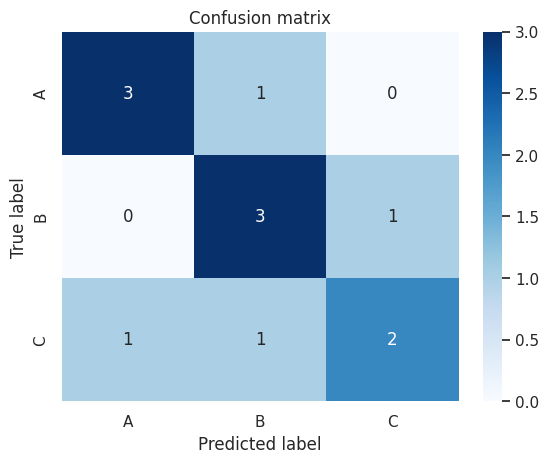

In [3]:
from sklearn.metrics import confusion_matrix

# toy example: true vs predicted labels for a 3-class problem
y_true = ["A","A","A","B","B","B","C","C","C","A","B","C"]
y_pred = ["A","A","B","B","B","C","C","A","C","A","B","B"]

cm = confusion_matrix(y_true, y_pred, labels=["A","B","C"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["A","B","C"], yticklabels=["A","B","C"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix")
plt.show()


This exact pattern is what you'll use to visualise how well any multi-class classifier
distinguishes between its classes — and it's far more informative than accuracy alone,
because it shows you **which specific classes get confused with which others**
(e.g. two visually or semantically similar categories).

### `sns.clustermap()`
Combines a heatmap with **hierarchical clustering**: it reorders rows and columns so that
similar ones sit next to each other, and draws dendrograms (tree diagrams) on the side
showing the clustering structure. Useful when you have many features/samples and want to
discover which ones naturally group together, without specifying the number of groups in
advance. Important preprocessing note: clustermap clusters based on raw distances, so
features on very different scales should typically be **standardised first**
(e.g. z-score), or the clustering will be dominated by whichever feature has the largest
numeric range.


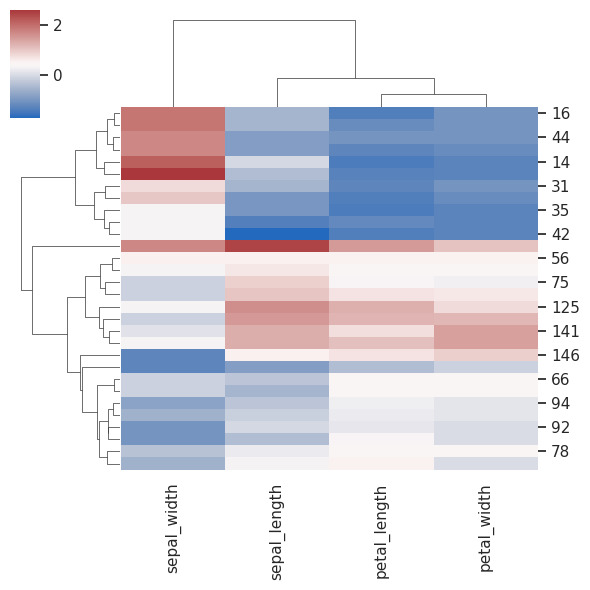

In [4]:
from scipy.cluster import hierarchy  # noqa (just confirming scipy is available)

# standardise numeric iris features before clustering, since petal/sepal are on
# different scales
iris_num = iris.drop(columns="species")
iris_std = (iris_num - iris_num.mean()) / iris_num.std()

sns.clustermap(iris_std.sample(30, random_state=1), cmap="vlag", figsize=(6, 6))
plt.show()


**Practice task:** Build a correlation heatmap for `penguins`' numeric columns. Which two
features are most strongly correlated? Would you consider dropping one of them before
training a model, and why might that matter for a simple linear model but matter less
for a tree-based model?


## Part 9 — Pairwise Relationships

### `sns.pairplot()`
Automatically plots every numeric column against every other numeric column as a grid of
scatter plots, with the diagonal showing each column's own distribution (histogram or
KDE). This is usually **one of the first plots** run during EDA, because in a single call
it gives you an overview of every feature relationship at once.

Key parameters: `hue` (colour by class — extremely useful for classification problems),
`diag_kind` (`"hist"` or `"kde"`), `corner=True` (only show the lower triangle, avoiding
duplicated mirrored plots), `vars=[...]` (restrict to specific columns when you have too
many to plot all pairs usefully).


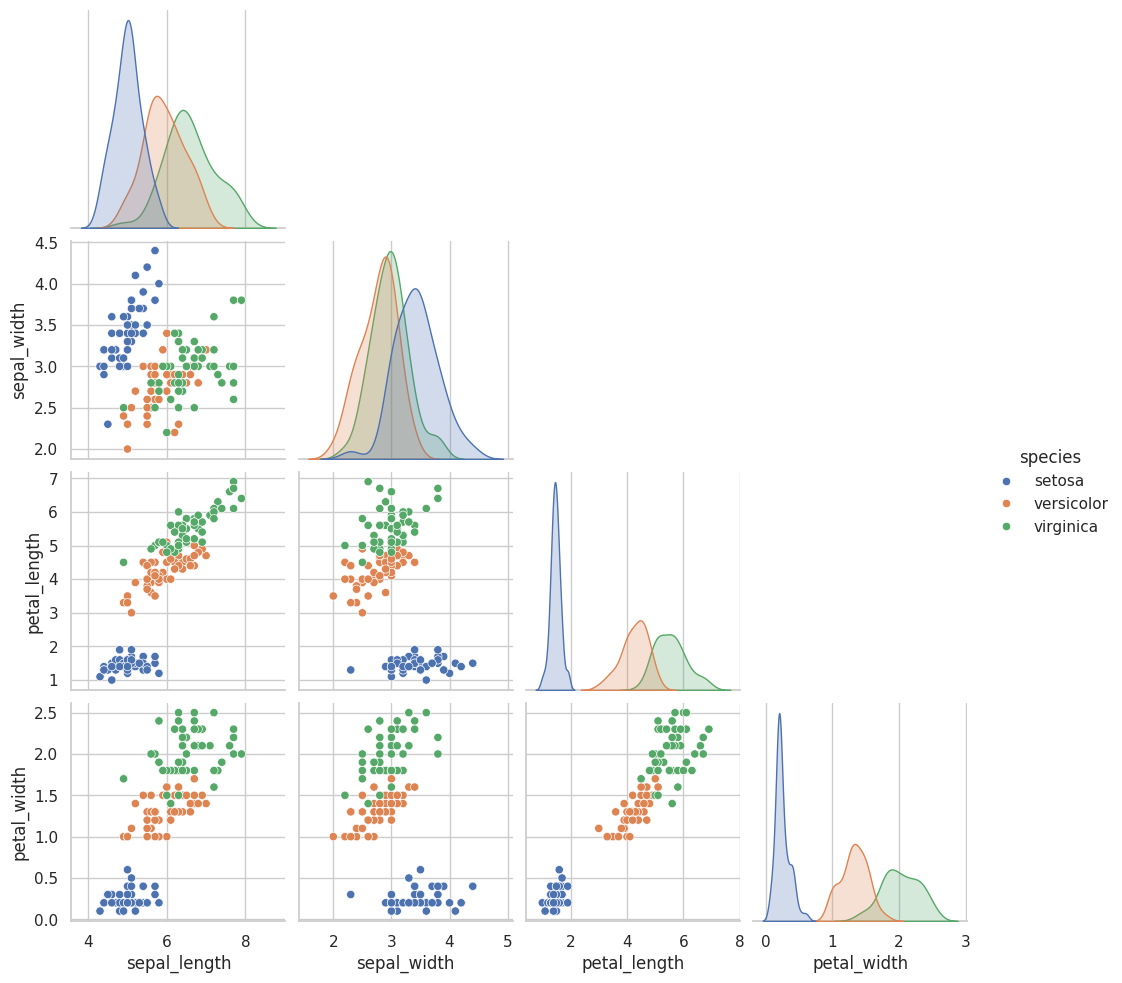

In [5]:
sns.pairplot(iris, hue="species", corner=True, diag_kind="kde")
plt.show()


This single plot already tells you `petal_length` and `petal_width` separate the three
iris species almost perfectly — a very strong signal that a simple classifier will do
well using just those two features.

**When pairplot becomes a bad idea:** with more than ~8–10 numeric columns, the grid
becomes huge, slow to render, and impossible to actually read. At that point, use a
correlation heatmap first to narrow down to the most interesting feature pairs, then
pairplot (or individual scatterplots) on just those.

### `sns.PairGrid()`
`pairplot()` is actually a convenient pre-configured wrapper around `PairGrid`. Use
`PairGrid` directly when you want **different plot types in different parts of the grid**
— e.g. scatter plots below the diagonal, KDE contours above it, and histograms on the
diagonal — which `pairplot()`'s simpler interface can't fully customise.


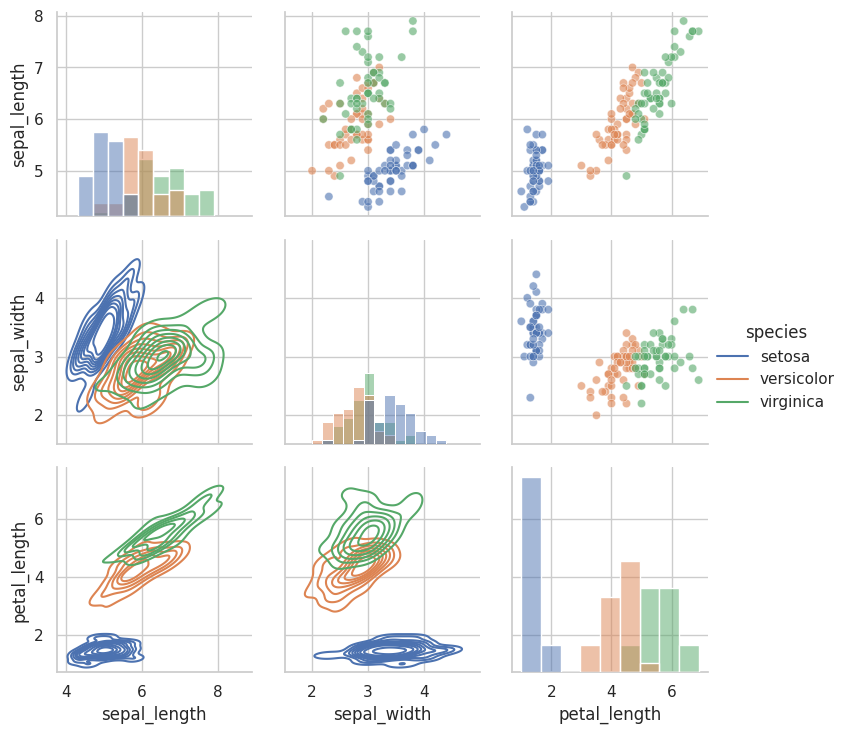

In [6]:
g = sns.PairGrid(iris, hue="species", vars=["sepal_length", "sepal_width", "petal_length"])
g.map_upper(sns.scatterplot, alpha=0.6)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
g.add_legend()
plt.show()


**`pairplot()` vs `PairGrid`**: start with `pairplot()` — it covers 90% of cases in one
line. Drop down to `PairGrid` only when you specifically need asymmetric plot types
across the grid, as above.

## Part 10 — FacetGrid

`sns.FacetGrid()` is the general-purpose engine behind `relplot`, `catplot`, and
`displot` — those functions are convenient wrappers around it. Use `FacetGrid` directly
when you want to facet a plot type that doesn't have its own figure-level wrapper.

Workflow: create the grid (specifying `row=`, `col=`, `hue=`), then call `.map()` or
`.map_dataframe()` with the plotting function you want applied to every facet.


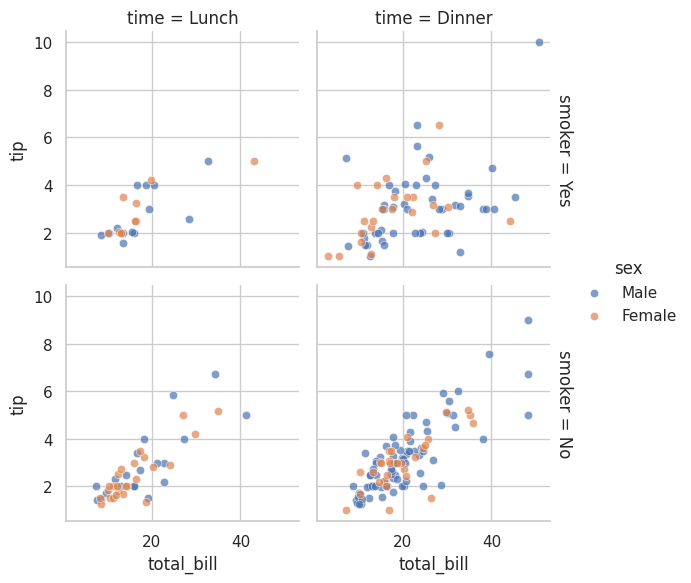

In [7]:
g = sns.FacetGrid(tips, col="time", row="smoker", hue="sex", height=3, margin_titles=True)
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip", alpha=0.7)
g.add_legend()
plt.show()


This is exactly the pattern you'd use in ML EDA to compare a relationship (e.g. two
features) across every combination of two categorical variables at once — here, whether
tipping behaviour differs by smoking status, meal time, and sex, all in one view. It
scales to comparing relationships across dataset splits, time periods, or class labels
just as easily.

## Part 11 — Joint Distributions

### `sns.jointplot()`
Shows the relationship between two variables in the centre, plus each variable's own
marginal distribution on the top and right edges — combining a relational plot with two
distribution plots in one figure. `kind=` controls the centre plot: `"scatter"`, `"reg"`
(adds a regression line), `"hist"`, `"kde"`, `"hex"` (hexagonal binning — better than
scatter for very dense data where points overlap heavily), or `"resid"` (residuals from a
linear fit).


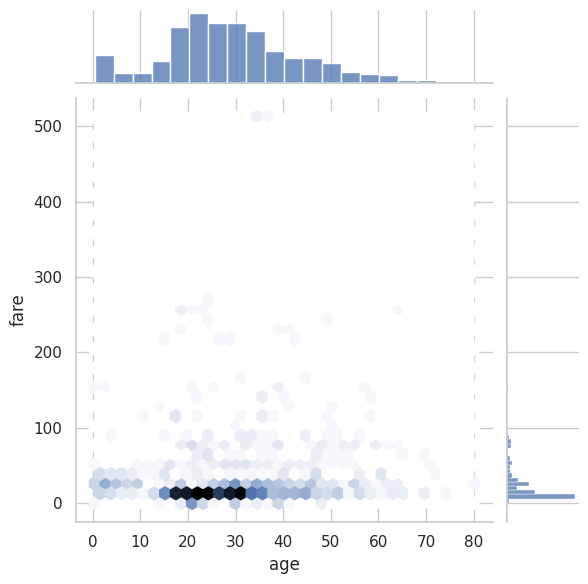

In [8]:
sns.jointplot(data=titanic, x="age", y="fare", kind="hex", height=6)
plt.show()


### `sns.JointGrid()`
Like `PairGrid` relates to `pairplot`, `JointGrid` is the customisable engine behind
`jointplot` — use it directly when you want a different plot type for the marginals than
for the centre (e.g. scatter in the centre, KDE for the margins, which is actually
`jointplot`'s default combination — but `JointGrid` lets you mix in ways `jointplot`'s
shortcuts don't cover).

**Practical ML use:** jointplot is a fast way to understand two features together —
their joint relationship *and* each one's individual distribution — without writing three
separate plot calls.


## Part 12 & 13 — Styling and Colour (Reference)

These are configuration functions — each is simple individually, so they're presented
here as a working reference rather than ten repeated explanations.

### Themes & context

| Function | What it controls |
|---|---|
| `sns.set_theme(style=..., context=...)` | one-call shortcut setting both style and context |
| `sns.set_style(style)` | background/gridlines: `"darkgrid"`, `"whitegrid"`, `"dark"`, `"white"`, `"ticks"` |
| `sns.set_context(context)` | scales font/line sizes for the target medium: `"paper"` (smallest, for print/papers), `"notebook"` (default), `"talk"`, `"poster"` (largest) |
| `sns.axes_style(style)` | inspect a style's settings as a dict, or use as a `with` block for temporary styling |
| `sns.plotting_context(context)` | same idea, for context |
| `sns.reset_defaults()` / `sns.reset_orig()` | undo Seaborn's styling and go back to Matplotlib defaults |

**Practical guidance:** use `"whitegrid"` for most ML/EDA notebooks (gridlines help you
read values off charts), switch `context` to `"talk"` or `"poster"` only when preparing
slides/posters for presentation — for figures going into a written report, `"notebook"`
or `"paper"` context at a reasonably large `figsize` is usually right.

### Colour palettes

| Category | Use for | Examples |
|---|---|---|
| Qualitative | distinct, unordered categories | `"deep"`, `"muted"`, `"bright"`, `"pastel"`, `"dark"`, `"Set2"`, `"colorblind"` |
| Sequential | ordered numeric data, no meaningful zero | `"viridis"`, `"Blues"`, `"rocket"` |
| Diverging | ordered numeric data **with** a meaningful zero/midpoint | `"coolwarm"`, `"RdBu_r"`, `"vlag"` |

`sns.color_palette(name)` returns the actual colour list (useful to preview with
`sns.color_palette(name)` in a notebook cell, which renders as swatches).
`palette=` is the parameter you pass into plotting functions; it works with `hue` to
assign colours to categories, or as a continuous colormap when `hue` is numeric
(`hue_norm` then controls how numeric values map onto the palette).

**Accessibility note, worth taking seriously for any report or public repo:** roughly 1 in 12
men have some form of colour vision deficiency. `palette="colorblind"` is specifically
designed to remain distinguishable under the most common forms of colour blindness — use
it for any figure going into your final report or a public GitHub repo, rather than the
default palette, unless you have a specific reason not to.


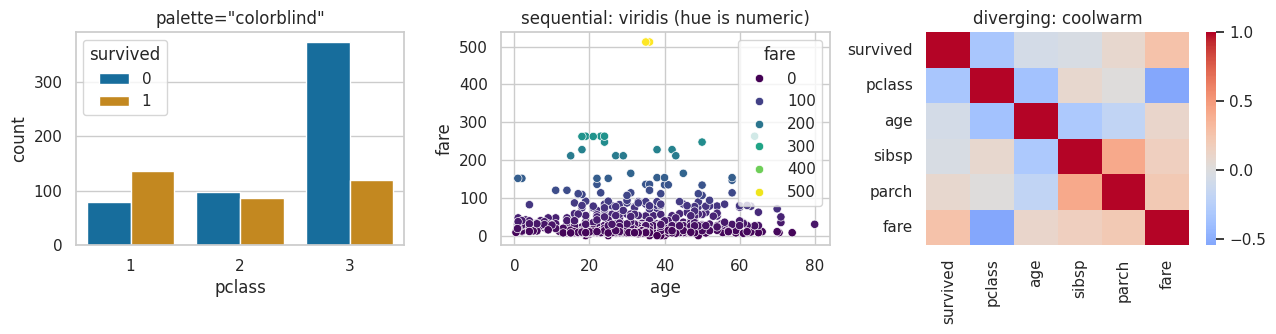

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sns.countplot(data=titanic, x="pclass", hue="survived", palette="colorblind", ax=axes[0])
axes[0].set_title('palette="colorblind"')

sns.scatterplot(data=titanic, x="age", y="fare", hue="fare", palette="viridis", ax=axes[1])
axes[1].set_title('sequential: viridis (hue is numeric)')

sns.heatmap(titanic.select_dtypes(include=[np.number]).corr(), cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title('diverging: coolwarm')

plt.tight_layout()
plt.show()


## Part 14 — The Statistics Behind Seaborn (Plain-Language Primer)

Seaborn's plots are visual wrappers around specific statistics. Understanding these
briefly means you can actually judge whether a plot's default behaviour is appropriate
for your data, rather than trusting it blindly.

- **Mean**: the average. Sensitive to outliers — one huge value can pull it a long way.
- **Median**: the middle value when sorted. Robust to outliers — this is why `boxplot`
  centres on the median rather than the mean.
- **Mode**: the most frequent value. Mainly relevant for categorical data (what
  `countplot` visualises).
- **Variance / Standard deviation**: how spread out values are around the mean. Standard
  deviation is in the same units as the original data (variance is squared units), which
  is why it's more commonly reported directly.
- **Percentiles / Quartiles / IQR**: a percentile is the value below which a given
  percentage of the data falls. Quartiles are the 25th/50th/75th percentiles; IQR (Q3 −
  Q1) measures the spread of the "middle half" of the data, robust to outliers — this is
  exactly what a box plot's box represents.
- **Probability density (KDE)**: a smooth curve where the *area* under any region equals
  the probability of a value falling in that region — the height alone is not a
  probability.
- **Confidence interval**: a range that's likely (e.g. 95% of the time, under repeated
  sampling) to contain the true population value being estimated (like a true mean). This
  is the shaded band around `lineplot`/`regplot` lines and the error bars on `barplot`.
- **Bootstrapping**: how Seaborn actually computes many of its confidence intervals — it
  repeatedly resamples your data (with replacement) and recomputes the statistic each
  time, using the spread of those repeated estimates as the interval, rather than
  assuming a specific mathematical formula.
- **Correlation vs Covariance**: covariance measures how two variables move together in
  their *original units* (making it hard to compare across variable pairs); correlation
  is covariance rescaled to always fall between −1 and 1, making it directly comparable
  across any pair of variables. `df.corr()` and `sns.heatmap()` use correlation, not raw
  covariance.

| Statistic | Where it shows up in Seaborn |
|---|---|
| Mean | `barplot` bar height (default `estimator`), `lineplot` line (default aggregation) |
| Median, quartiles, IQR | `boxplot` |
| Density/KDE | `kdeplot`, the KDE overlay in `histplot`/`displot` |
| Confidence interval (bootstrapped) | shaded band in `lineplot`/`regplot`, error bars in `barplot`/`pointplot` |
| Correlation | `heatmap` on a `.corr()` matrix |
| Linear/logistic regression fit | `regplot`, `lmplot` |


## Part 15–17 — Working With Pandas, NumPy, and Matplotlib

### Seaborn + Pandas
Seaborn is built to consume "tidy" DataFrames — one row per observation, one column per
variable. Common prep steps before plotting:

```python
df[["age", "fare"]]                       # select columns
df[df["pclass"] == 1]                     # filter rows
df.groupby("pclass")["fare"].mean()       # aggregate, then plot the summary directly
df.pivot_table(index="pclass", columns="survived", values="fare", aggfunc="mean")
df.melt(id_vars="species")                # wide → long format (often required before plotting)
df.dropna(subset=["age"])                 # handle missing values explicitly
df["pclass"] = df["pclass"].astype("category")   # correct dtype so Seaborn treats it as categorical, not numeric
```

Why DataFrame structure matters: `sns.boxplot(data=df, x="class", y="age")` only works
cleanly because `df` is tidy — one row per passenger. If your data were "wide" (e.g. one
column per class, containing ages), you'd need `melt()` first to reshape it into the
long/tidy format Seaborn expects.

### Seaborn + NumPy
Any Seaborn function will happily accept NumPy arrays directly instead of DataFrame
columns — useful for quickly visualising synthetic data (e.g. checking what a `np.random`
distribution actually looks like) without building a DataFrame first. Convert with
`pd.Series(arr)` or `pd.DataFrame({...})` when you need column names for `hue`/faceting.

### Seaborn + Matplotlib
This is the integration you'll use constantly for anything beyond a single quick plot.


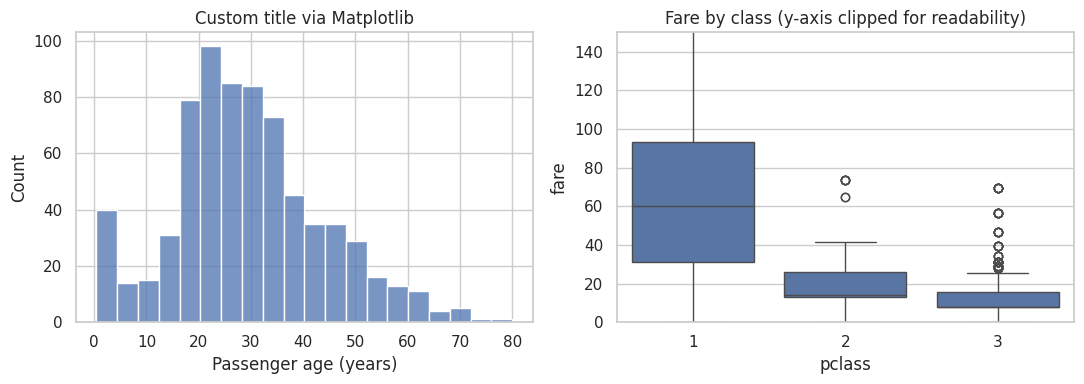

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=titanic, x="age", ax=axes[0])
axes[0].set_title("Custom title via Matplotlib")
axes[0].set_xlabel("Passenger age (years)")

sns.boxplot(data=titanic, x="pclass", y="fare", ax=axes[1])
axes[1].set_ylim(0, 150)          # zoom in, matplotlib call
axes[1].set_title("Fare by class (y-axis clipped for readability)")

plt.tight_layout()
plt.savefig("example_figure.png", dpi=150)  # matplotlib handles saving, not seaborn
plt.show()


The pattern `fig, ax = plt.subplots()` then `sns.something(..., ax=ax)` is how you build
multi-plot layouts and apply fine Matplotlib control (`set_xlim`, `set_title`,
`legend()`, `tight_layout()`, `savefig()`) on top of Seaborn's statistical plotting.
Remember: this only works cleanly with **axes-level** functions — figure-level functions
(`relplot`, `catplot`, `displot`, `lmplot`, `pairplot`, `jointplot`) manage their own
figure and don't take an `ax=` argument the same way (they return a Grid object with
`.fig` and `.axes` attributes instead, if you need to adjust them afterward).


## Part 18 — A Complete EDA Workflow (Titanic)

This is the routine you should run, roughly in this order, on **any** new dataset before
modelling — including a numeric-features dataset you've extracted from a custom
pipeline (e.g. sensor readings, embeddings, or engineered features).


In [11]:
# 1-6: Load & understand structure
print(titanic.shape)
print(titanic.dtypes)
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])
print("Duplicate rows:", titanic.duplicated().sum())


(891, 15)
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
Duplicate rows: 107


**What we learned:** `age` (~20% missing), `embarked`/`embark_town` (a couple missing),
`deck` (mostly missing — likely too sparse to use directly). No duplicate rows.


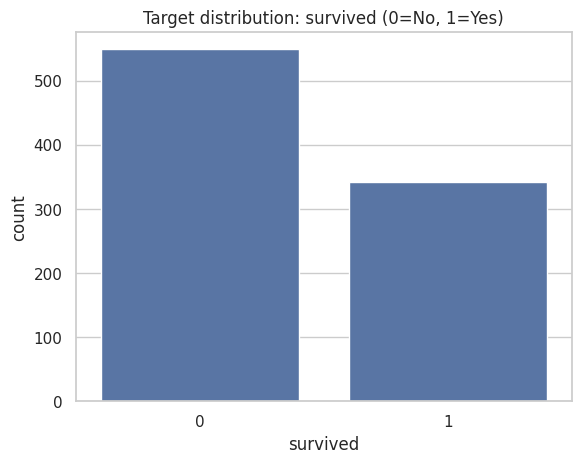

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [12]:
# 7: Target distribution (class imbalance check)
sns.countplot(data=titanic, x="survived")
plt.title("Target distribution: survived (0=No, 1=Yes)")
plt.show()
print(titanic["survived"].value_counts(normalize=True))


**What we learned:** about 62% did not survive, 38% did — noticeably imbalanced but not
extreme. Worth knowing before choosing an evaluation metric (accuracy alone can be
misleading on imbalanced data — precision/recall/F1 matter more).


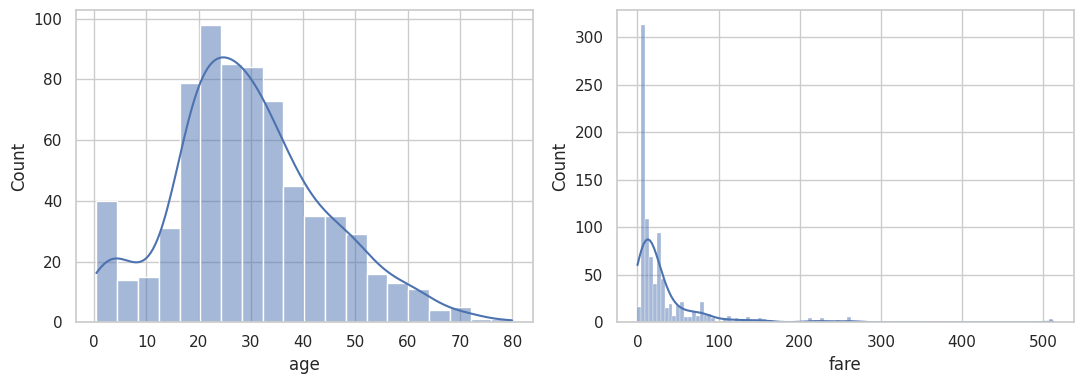

In [13]:
# 8-9: Univariate + bivariate numeric analysis
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=titanic, x="age", kde=True, ax=axes[0])
sns.histplot(data=titanic, x="fare", kde=True, ax=axes[1])
plt.tight_layout()
plt.show()


**What we learned:** `age` is roughly bell-shaped with a slight right skew (a cluster of
infants/young children too); `fare` is heavily right-skewed with a long tail of expensive
tickets — a strong candidate for a log transform if used in a linear model.


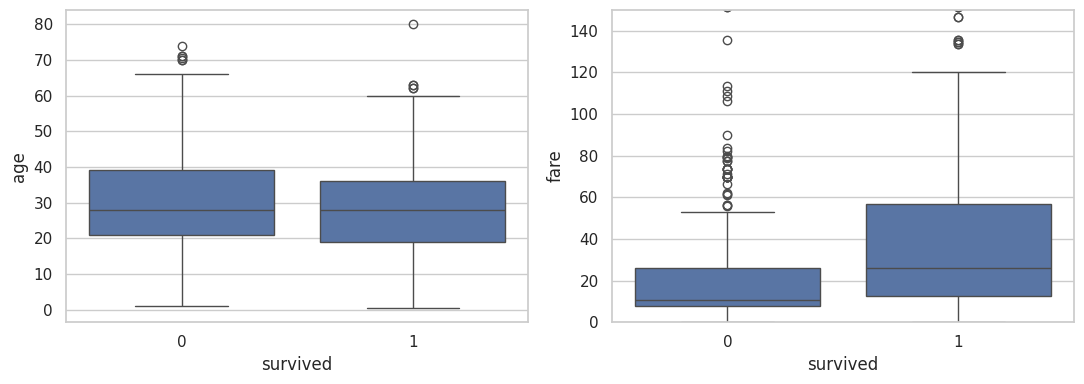

In [14]:
# 10-11: Feature-target relationships (numeric)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=titanic, x="survived", y="age", ax=axes[0])
sns.boxplot(data=titanic, x="survived", y="fare", ax=axes[1])
axes[1].set_ylim(0, 150)
plt.tight_layout()
plt.show()


**What we learned:** survivors paid noticeably higher fares on average; age shows a less
dramatic but still visible difference (survivors skew slightly younger).


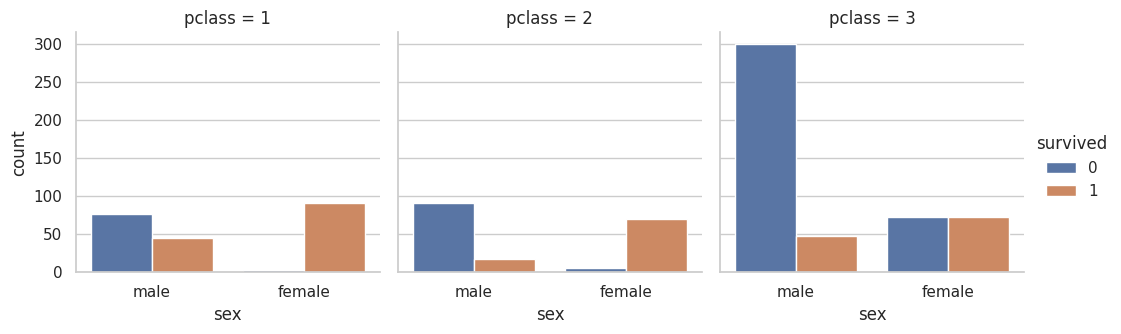

In [15]:
# 12: Categorical feature vs target
sns.catplot(data=titanic, x="sex", hue="survived", col="pclass", kind="count", height=3.5)
plt.show()


**What we learned:** sex and class are both strongly related to survival — women and
1st-class passengers survived at much higher rates. This is the single strongest signal
in the dataset and any reasonable classifier should pick it up easily.


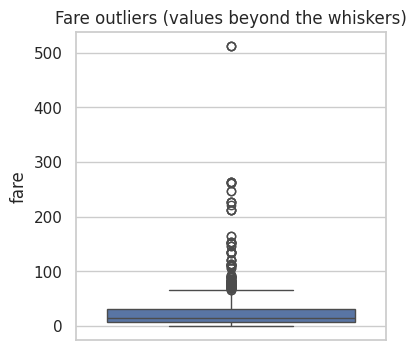

survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.077221
pclass     -0.338481
Name: survived, dtype: float64


In [16]:
# 13-14: Outliers + correlation
plt.figure(figsize=(4, 4))
sns.boxplot(data=titanic, y="fare")
plt.title("Fare outliers (values beyond the whiskers)")
plt.show()

corr = titanic.select_dtypes(include=[np.number]).corr(numeric_only=True)
print(corr["survived"].sort_values(ascending=False))


**Summary of EDA findings (this is the kind of paragraph that belongs in a
report's data analysis section):**

The Titanic dataset shows moderate class imbalance in the target (62/38 split), several
columns with meaningful missingness (`age`, `deck`, `embarked`) that must be handled
explicitly before modelling, a strongly right-skewed `fare` distribution suggesting a
transform for linear models, and clear, strong relationships between `survived` and both
`sex` and `pclass` — these should be treated as high-value features. `deck` is sparse
enough that it's a candidate for dropping or careful imputation rather than naive
filling. No duplicate rows were found, so deduplication is not required here.


## Part 19 — Seaborn Before Model Training

**For classification problems**, check: target class balance (`countplot`), per-class
feature distributions (`histplot`/`boxplot` with `hue`), and feature relationships
(`pairplot(hue=target)`, `heatmap`) — exactly what we just did above.

**For regression problems**, check: target distribution shape (`histplot` — is it
skewed? does it need a log transform?), feature-target relationships (`scatterplot` +
`regplot`), and correlation with the target (`heatmap`).

**For clustering (unsupervised) problems**, since there's no target/label to check
against, focus on: `pairplot`/`scatterplot` to visually look for natural groupings,
`heatmap`/`clustermap` for feature relationships and structure among samples, and
remember that any grouping you *see* visually should still be validated with an actual
clustering algorithm and metric (e.g. silhouette score) — a visual cluster is a
hypothesis, not a result.

## Part 20 — Visualising Model Evaluation

### Classification: confusion matrix (already shown in Part 8) + metrics


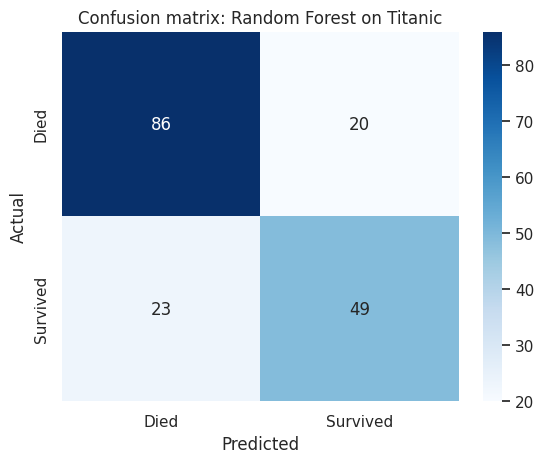

              precision    recall  f1-score   support

        Died       0.79      0.81      0.80       106
    Survived       0.71      0.68      0.70        72

    accuracy                           0.76       178
   macro avg       0.75      0.75      0.75       178
weighted avg       0.76      0.76      0.76       178



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

df = titanic.dropna(subset=["age", "embarked"]).copy()
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].astype("category").cat.codes

features = ["pclass", "sex", "age", "fare", "sibsp", "parch", "embarked"]
X = df[features]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix: Random Forest on Titanic")
plt.show()

print(classification_report(y_test, preds, target_names=["Died", "Survived"]))


**Reading a confusion matrix:** the diagonal (top-left, bottom-right here) is correct
predictions. Off-diagonal cells are errors — top-right is **False Positives** (predicted
survived, actually died), bottom-left is **False Negatives** (predicted died, actually
survived). From these: **Precision** = of everything predicted positive, how much was
actually positive; **Recall** = of everything actually positive, how much did we catch;
**F1** = harmonic mean of precision and recall, useful as a single number when you care
about both. Which error type matters more depends entirely on your application — for a
medical screening system, a False Negative (missing a real positive case) is often far
worse than a False Positive, because it lets a real problem go undetected rather than
just triggering an unnecessary follow-up.

### Classification metrics as a heatmap


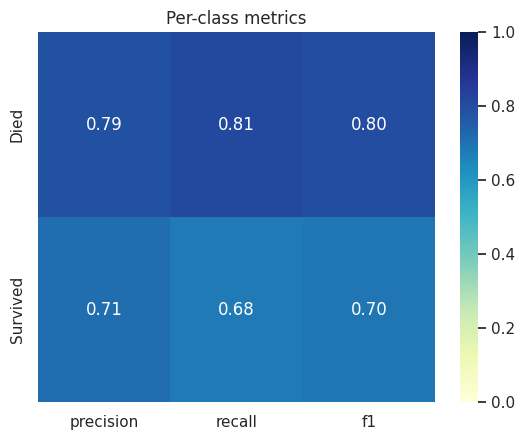

In [18]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, preds)
metrics_df = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                           index=["Died", "Survived"])

sns.heatmap(metrics_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Per-class metrics")
plt.show()


### Regression evaluation: actual vs predicted, and residuals


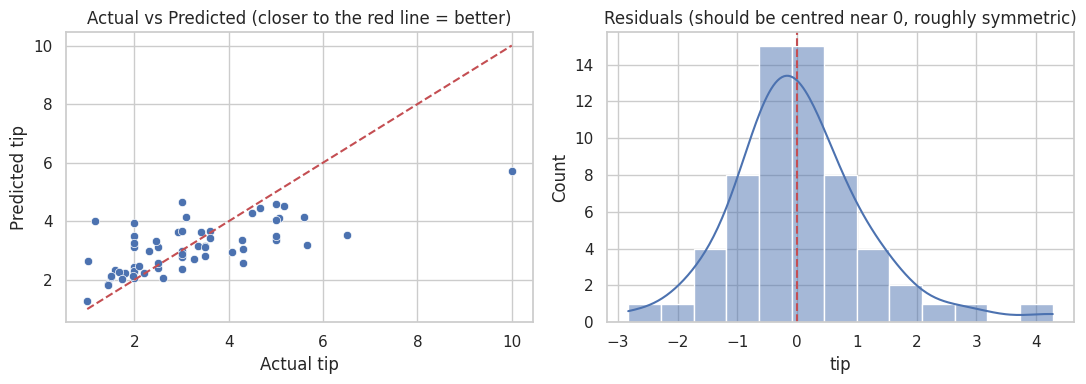

In [19]:
from sklearn.linear_model import LinearRegression

reg_df = tips.copy()
Xr = reg_df[["total_bill", "size"]]
yr = reg_df["tip"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=1)

lr = LinearRegression().fit(Xr_train, yr_train)
yr_pred = lr.predict(Xr_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(x=yr_test, y=yr_pred, ax=axes[0])
axes[0].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], "r--")
axes[0].set_xlabel("Actual tip")
axes[0].set_ylabel("Predicted tip")
axes[0].set_title("Actual vs Predicted (closer to the red line = better)")

residuals = yr_test - yr_pred
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_title("Residuals (should be centred near 0, roughly symmetric)")

plt.tight_layout()
plt.show()


**Diagnosing model behaviour from these plots:** in the left plot, points clustering
tightly around the diagonal red line mean good predictions; a systematic curve or fan
shape (spreading wider at one end) suggests the model is missing a non-linear pattern, or
that error variance isn't constant across the range (heteroscedasticity). In the right
plot, residuals centred at 0 with roughly symmetric spread are a good sign; a skewed or
off-centre residual distribution suggests the model is systematically over- or
under-predicting in some region.

## Part 21 — Seaborn for Feature Engineering

Visualisation should directly drive these decisions, not just illustrate them after the
fact:

- **Right-skewed feature** (long tail, seen via `histplot`) → consider `np.log1p()`
  transform before feeding to a linear/distance-based model.
- **Very different feature scales** (seen by comparing `boxplot`s side by side) → apply
  scaling (standardisation or min-max) — especially important for distance-based models
  and neural networks, less so for tree-based models.
- **Highly correlated feature pairs** (seen via `heatmap`, e.g. |r| > 0.9) → consider
  dropping one; redundant features add noise and can hurt some models' interpretability
  and stability without adding predictive power.
- **Non-linear feature-target relationship** (seen via `regplot` with `order=2` fitting
  much better than `order=1`) → consider a polynomial feature, binning, or switching to a
  non-linear model.
- **Class imbalance** (seen via `countplot` on the target) → consider class weights,
  resampling, or a metric other than raw accuracy — especially relevant for any dataset
  where some classes are naturally easier or faster to collect than others.

## Part 22 — Seaborn for Deep Learning

Seaborn isn't a deep learning library, but it's exactly the right tool for visualising
what a DL framework (TensorFlow/Keras, PyTorch) produces as its training history.


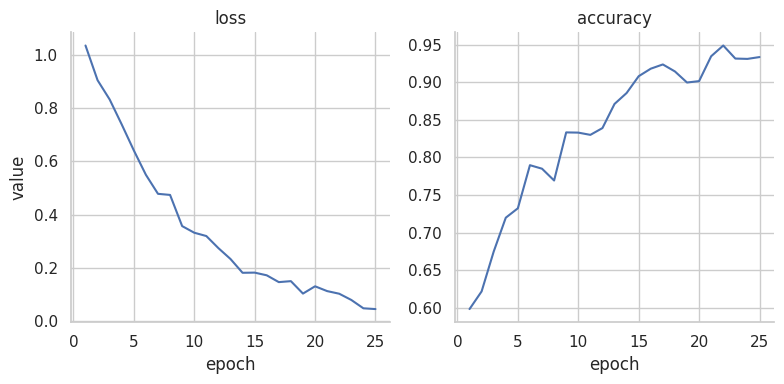

In [20]:
# Simulated Keras-style training history, as you would get from model.fit(...).history
history_dict = {
    "epoch": list(range(1, 26)) * 2,
    "value": list(1.2 * np.exp(-np.arange(1, 26)/8) + np.random.normal(0, 0.02, 25)) +
             list(0.55 + 0.4 * (1 - np.exp(-np.arange(1, 26)/8)) + np.random.normal(0, 0.015, 25)),
    "metric": ["loss"] * 25 + ["accuracy"] * 25,
    "split": (["train"] * 12 + ["val"] * 13) * 2  # just for illustration
}
hist_df = pd.DataFrame(history_dict)

g = sns.relplot(data=hist_df, x="epoch", y="value", col="metric", kind="line",
                 facet_kws={"sharey": False}, height=4)
g.set_titles("{col_name}")
plt.show()


This exact pattern — convert `model.fit(...).history` (a dict of lists) into a long-format
DataFrame with `melt()`, then `sns.lineplot`/`relplot` — is what you'll use to produce
training curves for any Keras/PyTorch model you train, including spotting overfitting
(validation metric plateauing or worsening while the training metric keeps improving)
directly from the plot.


## Part 23 — Advanced Notes & Performance

- **Figure-level vs axes-level** — covered in Part 1; remember figure-level functions
  return a Grid object (`.fig`, `.axes`), not a single `Axes`.
- **Custom estimators**: pass any function to `estimator=` (e.g. `estimator=np.median`)
  in `barplot`/`pointplot`/`lineplot` when you suspect outliers are skewing the mean.
- **Weighted observations**: some functions accept `weights=` for weighted statistics —
  relevant if your dataset has sampling weights (uncommon in typical student/portfolio
  project datasets, but worth knowing exists).
- **Large datasets / overplotting**: for tens of thousands+ of points, plain
  `scatterplot` becomes slow and visually just a solid blob. Mitigations: lower `alpha`,
  switch to `sns.histplot(..., bins=..)` in 2D (a density heatmap of the two variables),
  use `kind="hex"` in `jointplot`, or **sample** the data (`df.sample(5000)`) purely for
  visualisation — never for training, but perfectly valid for exploration.
- **Masking**: used in `heatmap(mask=...)` (shown in Part 8) to hide redundant or
  irrelevant cells.

## Part 24 — Function Reference Table


| Function | Purpose | Category | Common ML use |
|---|---|---|---|
| `scatterplot` | points on x/y | Relational (axes) | correlation, clusters, outliers |
| `lineplot` | trend over ordered x, auto-aggregates | Relational (axes) | training/validation curves |
| `relplot` | scatter/line + faceting | Relational (figure) | comparing relationships across groups |
| `histplot` | binned counts | Distribution (axes) | feature/target distribution, skew, imbalance |
| `kdeplot` | smoothed density | Distribution (axes) | comparing distribution shapes across classes |
| `ecdfplot` | cumulative distribution | Distribution (axes) | precise "% below X" claims, no binning bias |
| `rugplot` | tick per observation | Distribution (axes) | showing raw points under a KDE/hist |
| `displot` | hist/kde/ecdf + faceting | Distribution (figure) | multi-panel distribution comparison |
| `countplot` | category frequency | Categorical (axes) | class imbalance |
| `barplot` | mean (or other stat) per category | Categorical (axes) | comparing an aggregated numeric value across groups |
| `boxplot` | 5-number summary per category | Categorical (axes) | spread + outliers per class |
| `violinplot` | box + KDE per category | Categorical (axes) | multi-modal distribution comparison |
| `stripplot` | jittered raw points | Categorical (axes) | small-data raw point view |
| `swarmplot` | non-overlapping raw points | Categorical (axes) | small-data exact point view |
| `pointplot` | mean + CI, connected | Categorical (axes) | trend across ordered categories/groups |
| `catplot` | any categorical kind + faceting | Categorical (figure) | multi-panel categorical comparison |
| `regplot` | scatter + fitted line | Regression (axes) | quick linear/logistic relationship check |
| `lmplot` | regplot + faceting/grouping | Regression (figure) | comparing fitted relationships across groups |
| `heatmap` | 2D grid as colour | Matrix (axes) | correlation matrices, confusion matrices |
| `clustermap` | heatmap + hierarchical clustering | Matrix (figure) | discovering feature/sample groupings |
| `pairplot` | every numeric pair | Pairwise (figure) | first-look EDA overview |
| `PairGrid` | customisable pairwise grid | Pairwise (figure) | mixed plot types across a pairwise grid |
| `FacetGrid` | general faceting engine | Multi-plot (figure) | custom faceted plots beyond built-in kinds |
| `jointplot` | relationship + two marginals | Joint (figure) | understanding two features together, quickly |
| `JointGrid` | customisable joint plot | Joint (figure) | mixed plot types for centre vs marginals |

Configuration (not plots): `set_theme`, `set_style`, `set_context`, `set_palette`,
`color_palette`, `axes_style`, `plotting_context`, `reset_defaults`, `reset_orig`.


## Part 25 — Common Mistakes (Checklist)

- Using wrong or mismatched `x`/`y` columns for the plot type you chose
- Forgetting `data=` and losing the ability to use `hue`/`style`/`size` by column name
- Confusing `countplot` (counts rows) with `barplot` (averages a numeric column)
- Reading correlation as causation
- Reading a KDE's peak height as a probability instead of a density
- Using too many colours/categories in one `hue`, making the legend unreadable
- Overusing `pairplot` on datasets with too many numeric columns
- Cramming too many categories onto one categorical axis (rotate labels or facet instead)
- Ignoring missing values — Seaborn silently drops NaNs, quietly reducing your effective sample size
- Ignoring outliers instead of investigating whether they're data errors or real extreme cases
- Misreading a confidence-interval band as a full prediction range
- Using a non-colourblind-safe palette for a public or graded report
- Building a misleading chart via a truncated y-axis or inconsistent scales across comparable subplots
- Treating a `regplot`/`lmplot` fitted line as "model evaluation" instead of exploratory visualisation (see Part 7)
- **Data leakage during EDA**: computing statistics (like scaling parameters, or even
  just "interesting feature" decisions) using your **test set**, then using those
  decisions to build your model — this silently leaks test information into training and
  inflates your reported performance. Always split train/test **before** doing any EDA
  that will influence modelling choices, or at minimum be disciplined about only ever
  fitting transformations on the training set.
- Plotting already-scaled data without labelling it as such, making later interpretation
  of "what does 1.5 mean here" confusing for readers of your report

## Part 26 — Best Practices Checklist

- Choose the plot type that answers your actual question, not the one that "looks nice"
- Always label axes with units where relevant (e.g. "Age (years)", not just "age")
- Give every figure in a report a clear, specific title — not "Figure 1"
- Prefer colourblind-safe palettes for anything shared publicly or submitted for grading
- Avoid decorative 3D effects, unnecessary gridlines, or excessive colour — they add
  noise, not information
- Keep a consistent style/palette across all figures in one report for visual coherence
- Explicitly state what each figure shows in the surrounding text — a figure without an
  interpretation sentence is doing half its job
- Tie every visualisation back to a concrete question: "what decision does this plot help
  me make?" If you can't answer that, reconsider whether the plot belongs in the report


## Part 27 — Complete Mini Projects

### Project 1 — Titanic EDA
Already largely completed in Part 18 above. Findings: sex and class are the two strongest
survival predictors; fare is right-skewed; age and embarked have missing values requiring
explicit handling; moderate class imbalance in the target.

### Project 2 — Iris EDA


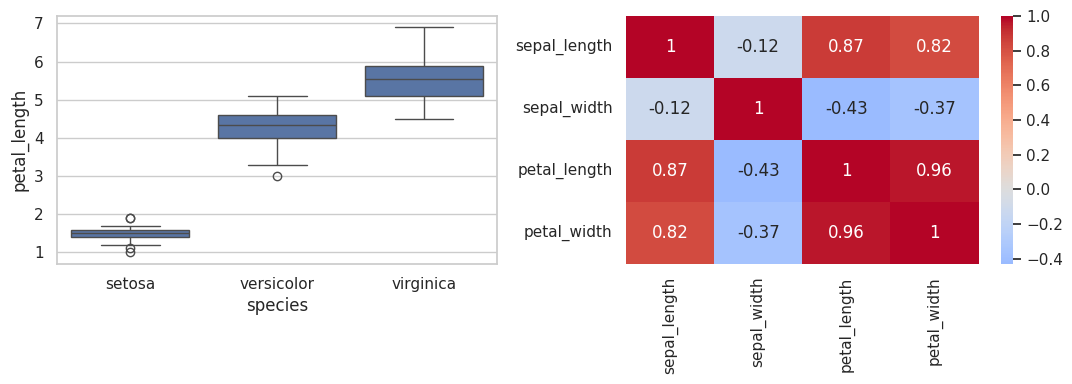

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=iris, x="species", y="petal_length", ax=axes[0])
sns.heatmap(iris.drop(columns="species").corr(), annot=True, cmap="coolwarm", center=0, ax=axes[1])
plt.tight_layout()
plt.show()


**Findings:** `petal_length` and `petal_width` are both highly correlated with each other
and cleanly separate species (seen earlier in the Part 9 pairplot) — species classification
here is close to trivial for even a simple model, because the classes are close to
linearly separable in just two features.

### Project 3 — Diamonds (price) EDA


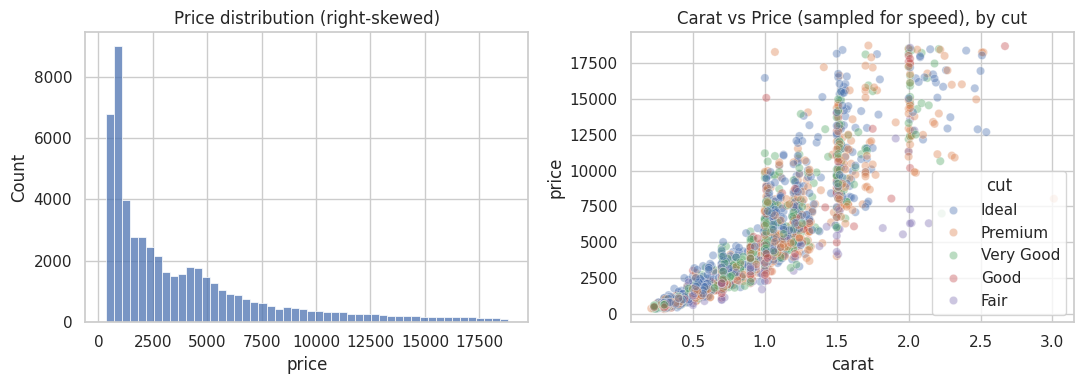

In [22]:
diamonds = sns.load_dataset("diamonds")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(diamonds["price"], bins=50, ax=axes[0])
axes[0].set_title("Price distribution (right-skewed)")

sns.scatterplot(data=diamonds.sample(3000, random_state=1), x="carat", y="price",
                 hue="cut", alpha=0.4, ax=axes[1])
axes[1].set_title("Carat vs Price (sampled for speed), by cut")

plt.tight_layout()
plt.show()


**Findings:** price is strongly right-skewed (a log transform is standard practice
before regression here); `carat` has a clear strong non-linear relationship with `price`
(price grows faster than linearly with size), which is why real diamond-price models
usually log-transform both `price` and `carat`, or use a tree-based model that doesn't
require linearity.

### Project 4 — Classification: class imbalance + confusion matrix
Covered fully in Part 20 with the Random Forest example on Titanic — countplot for
imbalance, heatmap for the confusion matrix, classification_report for precision/recall/F1.

### Project 5 & 6
Projects 5 (model diagnostics) and 6 (deep learning training curves) are covered in full
in Parts 20 and 22 respectively, using code patterns you can reuse directly for any
classifier or deep learning model you train.




## Part 28 — Practice Exercises

**Level 1 (Easy):** Load `penguins`, plot a histogram of `body_mass_g`.
**Level 2 (Beginner ML):** Plot `body_mass_g` split by `species` using `boxplot`, and
identify which species has the widest spread.
**Level 3 (Intermediate):** Build a correlation heatmap of all numeric `penguins`
columns and identify the two most correlated features.
**Level 4 (Advanced):** Build a `pairplot` with `hue="species"` and identify which two
features alone would likely separate the species best.
**Level 5 (Real-world AI/ML):** Train a simple classifier (e.g. `RandomForestClassifier`)
on `penguins` to predict `species`, then visualise its confusion matrix and per-class
precision/recall as heatmaps, following the exact pattern from Part 20.

*(Deliberately no solutions provided inline — work through them using the patterns shown
throughout this notebook; that repetition is what builds real fluency.)*

## Part 29 — Final Cheat Sheet


```python
import seaborn as sns
import matplotlib.pyplot as plt

# Common plots
sns.scatterplot(data=df, x=.., y=.., hue=..)
sns.lineplot(data=df, x=.., y=.., hue=..)
sns.histplot(data=df, x=.., hue=.., kde=True)
sns.kdeplot(data=df, x=.., hue=.., fill=True)
sns.boxplot(data=df, x=.., y=..)
sns.violinplot(data=df, x=.., y=..)
sns.barplot(data=df, x=.., y=.., estimator=..)
sns.countplot(data=df, x=..)
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
sns.pairplot(df, hue=..)
sns.regplot(data=df, x=.., y=.., order=1)

# Common parameters
# data, x, y, hue, style, size, palette, kind, row, col, ax

# ML EDA workflow
# Load -> Understand (shape/dtypes/nulls) -> Clean -> Univariate ->
# Bivariate -> Multivariate -> Correlation -> Outliers ->
# Feature relationships -> Feature engineering -> Model training ->
# Model evaluation -> Error analysis
```

---
